# Import Labiraries

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
!pip install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 8.9 MB/s eta 0:00:00


In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# for Data Augmentation
import random
import nlpaug.augmenter.word as naw
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')  
nltk.download('wordnet')                         
nltk.download('omw-1.4')     

# for preprocessing & modeling
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer ,BertForSequenceClassification, Trainer , TrainingArguments
import torch
from torch.utils.data import Dataset
from sklearn.metrics import classification_report


2025-08-29 14:07:39.866266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756476460.024813      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756476460.072865      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nl

# Data Overview

In [4]:
df = pd.read_csv(r"/kaggle/input/resume-dataset/Resume/Resume.csv")
df.sample(10)  # display 10 random samples

,ID,Resume_str,Resume_html,Category
1905,19446337,SENIOR ACCOUNTANT Summary ...,"<div class=""fontsize fontface vmargins hmargin...",ACCOUNTANT
31,18316239,HR GENERALIST Professional Prof...,"<div class=""fontsize fontface vmargins hmargin...",HR
2305,22848179,DIRECTOR OF COMMUNITY Ski...,"<div class=""fontsize fontface vmargins hmargin...",ARTS
2346,34304175,WAREHOUSE LEAD Executive Pr...,"<div class=""fontsize fontface vmargins hmargin...",ARTS
1289,10005171,MEDIA ACTIVITIES SPECIALIST Sum...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA
430,86322251,READING TEACHER Summary ...,"<div class=""fontsize fontface vmargins hmargin...",TEACHER
2202,27606527,SOFTWARE QUALITY ASSURANCE ANALYST II...,"<div class=""fontsize fontface vmargins hmargin...",BANKING
604,26278597,BUSINESS DEVELOPMENT MANAGER Su...,"<div class=""fontsize fontface vmargins hmargin...",BUSINESS-DEVELOPMENT
1955,63145386,CONSTRUCTION PROJECT MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",CONSTRUCTION
1542,29998869,DIRECTOR OF FINANCE Summary ...,"<div class=""fontsize fontface vmargins hmargin...",FINANCE


In [5]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

- ID: Unique identifier and file name for the respective pdf.
- Resume_str : Contains the resume text only in string format.
- Resume_html : Contains the resume data in html format as present while web scrapping.
- Category : Category of the job the resume was used to apply.

In [6]:
# drop [ID , Resume_html] 
df.drop(columns = ["ID","Resume_html"] , axis =1, inplace=True)
df

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,GEEK SQUAD AGENT Professional...,AVIATION
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


In [7]:
# get summary of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Resume_str  2484 non-null   object
 1   Category    2484 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB


In [8]:
df.shape

(2484, 2)

In [9]:
# check duplictaes
df[df.duplicated()]

,Resume_str,Category
1509,FINANCE OFFICER Professional ...,FINANCE
2483,STOREKEEPER II Professional Sum...,AVIATION


In [10]:
# drop duplictaes
df.drop_duplicates(inplace= True)

In [11]:
df.shape

(2482, 2)

In [12]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   117
FITNESS                   117
SALES                     116
AVIATION                  116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

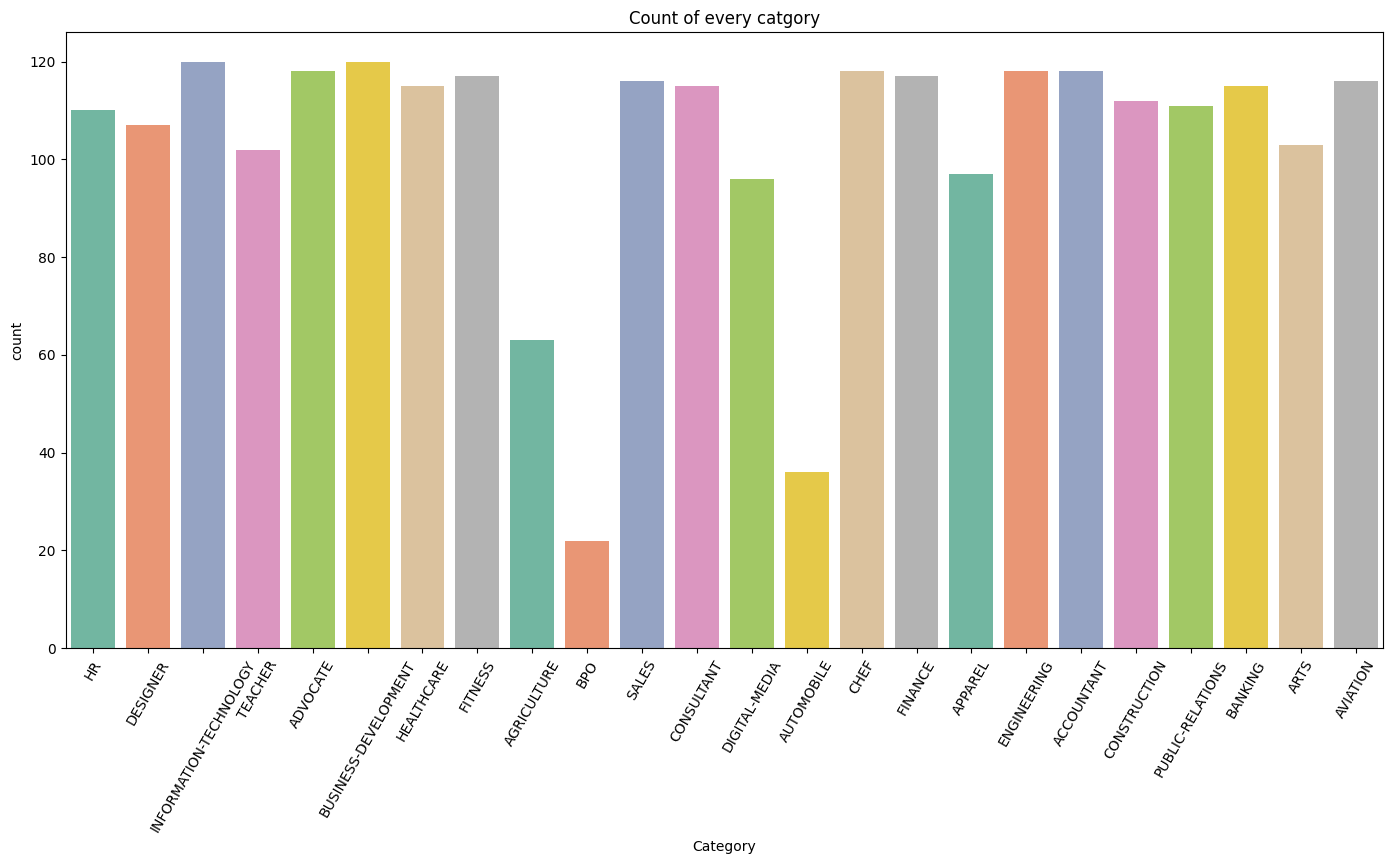

In [13]:
plt.figure(figsize=(17,8))
sns.countplot(df, x ="Category",palette="Set2")
plt.title("Count of every catgory")
plt.xticks(rotation =60)
plt.show()

# Data Augmentation

In [14]:
df_counts = df['Category'].value_counts()
target = 120

# prepare augmentation
eda_aug = naw.ContextualWordEmbsAug(model_path='distilbert-base-uncased', action="substitute")
wordnet_aug = naw.SynonymAug(aug_src='wordnet')
eda_swap = naw.RandomWordAug(action="swap")

new_rows = []
for cat , count in df_counts.items():
    if count >= target:
        continue
    samples = df[df["Category"] == cat]["Resume_str"].tolist()

    needed = target-count
    i = 0

    while i < needed:
        src = random.choice(samples)
        if i%3 ==0 :
            aug = wordnet_aug.augment(src)
        elif i % 3 == 1:
            aug = eda_aug.augment(src)
        else:
            aug = eda_swap.augment(src)
            
        new_rows.append({'Resume_str': aug, 'Category': cat})
        i += 1

df_aug = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
df_aug

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

The following layers were not sharded: distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.embeddings.word_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.q_lin.bias, vocab_layer_norm.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.v_lin.bias, distilbert.transformer.layer.*.attention.out_lin.bias, vocab_projector.bias, distilbert.embeddings.LayerNorm.weight, distilbert.embeddings.position_embeddings.weight, vocab_transform.weight, vocab_projector.weight, distilbert.transformer.layer.*.attention.k_lin.weight, vocab_layer_norm.bias, distilbert.transformer.layer.*.ffn.lin*.bias, distilbert.transformer.layer.*.ffn.lin*.weight, vocab_transfor

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2875,[TRANSACTION PROCESSING ANALYST Summary Depend...,BPO
2876,[test analyst - intern / contractor profile 3 ...,BPO
2877,[SR. CAMPUS RECRUITER Summary Solutions and re...,BPO
2878,[QUALITY ASSURANCE LEAD Career Overview Coachi...,BPO


# BERT Tokenizer

In [15]:
# split Data
texts = df_aug["Resume_str"]
labels = df_aug["Category"]

# convert texts , labels to list (since bert tokenizer must take list)
texts = texts.tolist()
labels = labels.tolist()


In [16]:
# encode categories
le = LabelEncoder()
labels = le.fit_transform(labels)
labels

array([19, 19, 19, ...,  8,  8,  8])

In [17]:
len(le.classes_) # number of classes

24

In [18]:
# split data to train & test

x_train , x_test , y_train,y_test = train_test_split(texts , labels , test_size=0.2,random_state=41)

In [19]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                     num_labels = len(le.classes_))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

The following layers were not sharded: bert.embeddings.token_type_embeddings.weight, bert.embeddings.position_embeddings.weight, classifier.weight, bert.encoder.layer.*.attention.self.key.bias, bert.encoder.layer.*.attention.self.query.bias, bert.embeddings.word_embeddings.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.output.LayerNorm.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.attention.self.value.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.pooler.dense.bias, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, classifier.bias, ber

In [20]:
type(x_train[0])

str

In [21]:
x_train = [str(x) for x in x_train]
x_test  = [str(x) for x in x_test]


In [22]:

encodings_train = tokenizer(
    x_train, 
    truncation=True,     # truncate sequences longer than 128 tokens
    padding=True,        # pad sequences shorter than 128 tokens
    max_length=128
)

encodings_test = tokenizer(
    x_test,
    truncation=True,
    padding=True,
    max_length=128
)


encodings is dictanary have {inout_id : attention_mask}

In [23]:
# class for convert train,test to Torch.Datset so Bert model expect this type

class Resume_Screening(Dataset):
    def __init__(self,encodings,labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self,idx):
        item = {key : torch.tensor(val[idx])  for key ,val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# prepare Dataset
train_dataset = Resume_Screening(encodings_train , y_train)
test_dataset = Resume_Screening(encodings_test , y_test) 

When using the HuggingFace Transformers library (like BERT or DistilBERT) with PyTorch, the model expects the data to be in the form of a torch.utils.data.Dataset.

The Dataset class is responsible for:

- Defining the data you have (the tokenized sentences + their labels).

- Explaining how to return one single sample (a sentence + its label) whenever the model requests it.

- Providing the total length of the dataset (number of samples).



In [24]:
# fine_tuning

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=6,  
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,
    weight_decay=0.1,
    logging_dir="./logs",
    logging_steps=10,
    logging_first_step=True,
    logging_strategy="steps",
    report_to="none",
    save_steps=300,
    overwrite_output_dir=True,
    eval_strategy="epoch", 
    disable_tqdm=False
)

trainer = Trainer(model = model ,
                 args = training_args ,
                  train_dataset = train_dataset,
                 eval_dataset = test_dataset,
                 )

In [25]:
# start training
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.529700,2.216092
2,1.285700,1.146143
3,0.853000,0.859115
4,0.644300,0.796955
5,0.503900,0.746020
6,0.402600,0.723058


TrainOutput(global_step=432, training_loss=1.1959006347590022, metrics={'train_runtime': 216.02, 'train_samples_per_second': 63.994, 'train_steps_per_second': 2.0, 'total_flos': 909491422887936.0, 'train_loss': 1.1959006347590022, 'epoch': 6.0})

In [26]:
trainer.evaluate()

{'eval_loss': 0.723057746887207,
 'eval_runtime': 2.7558,
 'eval_samples_per_second': 209.017,
 'eval_steps_per_second': 6.532,
 'epoch': 6.0}

In [27]:
preds = trainer.predict(train_dataset)
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_train, y_pred, target_names=le.classes_))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.99      0.99      0.99        94
              ADVOCATE       0.98      0.90      0.93        96
           AGRICULTURE       0.98      0.95      0.96        97
               APPAREL       0.87      0.92      0.90       102
                  ARTS       0.94      0.85      0.89        98
            AUTOMOBILE       0.97      0.84      0.90        89
              AVIATION       0.95      0.96      0.95        91
               BANKING       0.94      0.96      0.95        98
                   BPO       0.91      1.00      0.95        93
  BUSINESS-DEVELOPMENT       1.00      1.00      1.00        97
                  CHEF       0.98      0.91      0.94        90
          CONSTRUCTION       0.99      0.99      0.99       103
            CONSULTANT       0.96      1.00      0.98        95
              DESIGNER       1.00      1.00      1.00        89
         DIGITAL-MEDIA       0.96      

In [28]:
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      1.00      0.98        26
              ADVOCATE       0.75      0.75      0.75        24
           AGRICULTURE       0.70      0.91      0.79        23
               APPAREL       0.41      0.67      0.51        18
                  ARTS       0.79      0.50      0.61        22
            AUTOMOBILE       0.91      0.65      0.75        31
              AVIATION       0.67      0.62      0.64        29
               BANKING       0.65      0.59      0.62        22
                   BPO       0.79      1.00      0.89        27
  BUSINESS-DEVELOPMENT       1.00      1.00      1.00        23
                  CHEF       0.93      0.93      0.93        30
          CONSTRUCTION       0.94      0.88      0.91        17
            CONSULTANT       0.85      0.88      0.86        25
              DESIGNER       1.00      1.00      1.00        31
         DIGITAL-MEDIA       0.85      

# DistilBert

In [29]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification


tokenizer_distil = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model_dsitil = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le.classes_)
)



encodings_train_distil = tokenizer_distil(
    x_train, 
    truncation=True,
    padding=True,
    max_length=128
)

encodings_test_distil = tokenizer_distil(
    x_test,
    truncation=True,
    padding=True,
    max_length=128
)

train_dataset_distil = Resume_Screening(encodings_train_distil , y_train)
test_dataset_distil = Resume_Screening(encodings_test_distil , y_test) 

The following layers were not sharded: distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.embeddings.word_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, classifier.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.q_lin.bias, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.v_lin.bias, distilbert.transformer.layer.*.attention.out_lin.bias, pre_classifier.weight, distilbert.embeddings.LayerNorm.weight, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.transformer.layer.*.ffn.lin*.bias, distilbert.transformer.layer.*.ffn.lin*.weight, pre_classifier.bias, classifier.bias, distilbert.transformer.layer.*.sa_layer_norm.weight,

In [30]:
# fine_tuning

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,  
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,
    weight_decay=0.1,
    logging_dir="./logs",
    logging_steps=10,
    logging_first_step=True,
    logging_strategy="steps",
    report_to="none",
    save_steps=300,
    overwrite_output_dir=True,
    eval_strategy="epoch", 
    disable_tqdm=False
)

trainer_distil = Trainer(model = model_dsitil ,
                 args = training_args ,
                  train_dataset = train_dataset_distil,
                 eval_dataset = test_dataset_distil,
                 )

In [31]:
trainer_distil.train()

Epoch,Training Loss,Validation Loss
1,1.956000,1.721120
2,1.219600,1.061705
3,0.812400,0.879686
4,0.689200,0.817027


TrainOutput(global_step=288, training_loss=1.4194259312417772, metrics={'train_runtime': 76.3165, 'train_samples_per_second': 120.76, 'train_steps_per_second': 3.774, 'total_flos': 305324630212608.0, 'train_loss': 1.4194259312417772, 'epoch': 4.0})

In [32]:
trainer_distil.evaluate()

{'eval_loss': 0.8170268535614014,
 'eval_runtime': 1.3424,
 'eval_samples_per_second': 429.074,
 'eval_steps_per_second': 13.409,
 'epoch': 4.0}

In [33]:
preds = trainer_distil.predict(train_dataset_distil)
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_train, y_pred, target_names=le.classes_))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      0.99      0.97        94
              ADVOCATE       0.96      0.79      0.87        96
           AGRICULTURE       0.80      0.77      0.79        97
               APPAREL       0.73      0.78      0.76       102
                  ARTS       0.81      0.64      0.72        98
            AUTOMOBILE       0.81      0.71      0.75        89
              AVIATION       0.87      0.84      0.85        91
               BANKING       0.88      0.81      0.84        98
                   BPO       0.78      0.97      0.87        93
  BUSINESS-DEVELOPMENT       0.99      0.99      0.99        97
                  CHEF       0.95      0.89      0.92        90
          CONSTRUCTION       1.00      0.97      0.99       103
            CONSULTANT       0.93      0.98      0.95        95
              DESIGNER       0.92      1.00      0.96        89
         DIGITAL-MEDIA       0.90      

In [34]:
preds = trainer_distil.predict(test_dataset_distil)
y_pred = preds.predictions.argmax(-1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.90      1.00      0.95        26
              ADVOCATE       0.94      0.71      0.81        24
           AGRICULTURE       0.79      0.83      0.81        23
               APPAREL       0.42      0.56      0.48        18
                  ARTS       0.79      0.50      0.61        22
            AUTOMOBILE       0.77      0.65      0.70        31
              AVIATION       0.73      0.66      0.69        29
               BANKING       0.76      0.59      0.67        22
                   BPO       0.71      1.00      0.83        27
  BUSINESS-DEVELOPMENT       0.96      1.00      0.98        23
                  CHEF       0.94      0.97      0.95        30
          CONSTRUCTION       1.00      0.82      0.90        17
            CONSULTANT       0.83      1.00      0.91        25
              DESIGNER       0.97      1.00      0.98        31
         DIGITAL-MEDIA       0.88      

In [35]:
model_dsitil.save_pretrained("./distilbert_saved")
tokenizer_distil.save_pretrained("./distilbert_saved")

('./distilbert_saved/tokenizer_config.json',
 './distilbert_saved/special_tokens_map.json',
 './distilbert_saved/vocab.txt',
 './distilbert_saved/added_tokens.json')